# Bitcoin Price Forecasting Using Machine Learning: Comparing Linear Regression, LSTM, Random Forest and XGBoost

## Objective
Predict the **daily closing price of Bitcoin (BTC-USD)** using a multivariate
dataset combining on-chain blockchain metrics, macroeconomic indicators,
and market sentiment proxies.

## Study Period
April 1, 2020 – April 1, 2025 | Daily frequency | ~1,826 observations

## Target Variable
`BTC_Close` — Daily closing price of Bitcoin in USD (source: CoinGecko)

## Feature Overview

| Category | Features | Source |
|---|---|---|
| Crypto market | BTC Volume, USDT Volume | CoinGecko |
| On-chain | Hash Rate, MVRV Ratio | Blockchain.com |
| Macro & liquidity | S&P 500, Fed Balance Sheet (WALCL), US Dollar Index, Gold | Investing.com / FRED |
| Sentiment & risk | Fear & Greed Index, VIX | Alternative.me / Investing.com |

## Models Evaluated
`Linear Regression` · `LSTM` · `Random Forest` · `XGBoost`

## Variable Selection Rationale

Features were selected based on their established relationship with Bitcoin
price dynamics in academic literature and practitioner research.

**On-chain metrics** capture the internal state of the Bitcoin network:
- `MVRV Ratio`: ratio of market value to realized value — a high MVRV signals
  that holders are in profit and may sell, historically coinciding with market tops
  (Sujatha et al., 2021)
- `Hash Rate`: measures total computational power securing the network;
  rising hash rate reflects miner confidence and network strength (King et al., 2024)

**Macro & liquidity indicators** reflect the broader financial environment:
- `WALCL` (Fed Balance Sheet): expansion through quantitative easing has
  historically preceded rallies in risk assets including Bitcoin (Tuteja, 2023)
- `S&P 500`: captures risk-on/risk-off sentiment; Bitcoin has shown positive
  correlation with equity markets in several periods (S&P Global, 2021)
- `US Dollar Index (DXY)`: a stronger dollar is historically associated with
  lower Bitcoin prices — a significant negative correlation (Ahmadova et al., 2024)
- `Gold`: acts as a traditional safe haven; mixed correlation with Bitcoin,
  positive during Bitcoin bull runs (Aliu et al., 2023)

**Sentiment & risk proxies** capture investor psychology:
- `Fear & Greed Index`: composite sentiment score (0–100) — extreme fear
  drives selling, extreme greed drives buying; strong correlation with BTC
  returns documented by Huang et al. (2024)
- `VIX`: the 'fear index' — high VIX signals market stress and risk-off
  behaviour, typically negative for Bitcoin (Aliu et al., 2023)

**Crypto liquidity:**
- `BTC Volume` & `USDT Volume`: trading activity and stablecoin-driven
  demand; rising USDT volume may precede price moves (Griffin & Shams, 2020)

In [110]:
# =============================================================================
# IMPORTS
# =============================================================================

# Standard library
import json

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Statistics
from scipy import stats

# Display settings
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [111]:
# =============================================================================
# GLOBAL CONFIGURATION
# =============================================================================

START_DATE = "2020-04-01"
END_DATE   = "2025-04-01"

# Complete daily date index for the study period
FULL_INDEX = pd.date_range(start=START_DATE, end=END_DATE, freq="D")

print(f"Study period      : {START_DATE} → {END_DATE}")
print(f"Total calendar days : {len(FULL_INDEX):,}")

Study period      : 2020-04-01 → 2025-04-01
Total calendar days : 1,827


In [112]:
# =============================================================================
# HELPER FUNCTION: Standardise any raw series to a continuous daily series
# =============================================================================

def to_daily(df, date_col, value_cols, date_format=None, fill_method="interpolate"):
    """
    Convert a raw DataFrame to a clean, gap-free daily series aligned
    to the global study period (FULL_INDEX).

    Parameters
    ----------
    df          : Raw input DataFrame
    date_col    : Name of the date column
    value_cols  : Columns to retain
    date_format : strptime format string; None = pandas auto-detect
    fill_method : 'interpolate' (default) for continuous data such as prices,
                  'ffill' for discrete/step data such as WALCL

    Returns
    -------
    pd.DataFrame with DatetimeIndex, no missing values, study period aligned
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], format=date_format, utc=True)
    df[date_col] = df[date_col].dt.tz_localize(None) if df[date_col].dt.tz is not None else df[date_col]
    df = df.set_index(date_col)[value_cols]
    df.index = df.index.normalize()
    df = df[~df.index.duplicated(keep="first")]  # drop duplicate dates if any
    df = df.reindex(FULL_INDEX)

    if fill_method == "interpolate":
        df = df.interpolate(method="linear").bfill()
    else:
        df = df.ffill().bfill()

    df.index.name = "Date"
    return df

print("Helper function to_daily() ready.")

Helper function to_daily() ready.


---
## Section 2 · Data Loading & Cleaning

Each data source required different handling due to varying formats (CSV, JSON)
and frequencies (daily, weekly). The unified `to_daily()` function standardises
all series to a continuous daily index over the study period.

Missing values arising from weekends and public holidays are filled via:
- **Linear interpolation** — for price/continuous series (BTC, Gold, DXY, etc.)
- **Forward fill** — for step/discrete series (WALCL — updated weekly by the Fed)

In [113]:
# -----------------------------------------------------------------------------
# BTC Close Price · BTC Volume · USDT Volume
# Source: CoinGecko (.csv)
# -----------------------------------------------------------------------------

btc_raw  = pd.read_csv("btc-usd-max.csv")
usdt_raw = pd.read_csv("usdt-usd-max.csv")

btc = to_daily(
    btc_raw,
    date_col    = "snapped_at",
    value_cols  = ["price", "total_volume"],
    fill_method = "interpolate"
).rename(columns={"price": "BTC_Close", "total_volume": "BTC_Volume"})

usdt = to_daily(
    usdt_raw,
    date_col    = "snapped_at",
    value_cols  = ["total_volume"],
    fill_method = "interpolate"
).rename(columns={"total_volume": "USDT_Volume"})

print(f"BTC  → {btc.shape[0]:,} rows | NaN: {btc.isna().sum().sum()}")
print(f"USDT → {usdt.shape[0]:,} rows | NaN: {usdt.isna().sum().sum()}")
btc.head(3)

BTC  → 1,827 rows | NaN: 0
USDT → 1,827 rows | NaN: 0


,BTC_Close,BTC_Volume
Date,,
2020-04-01,"6,421.71","32,287,674,952.18"
2020-04-02,"6,640.80","35,886,963,977.72"
2020-04-03,"6,807.90","47,638,672,293.74"


In [114]:
# -----------------------------------------------------------------------------
# S&P 500
# Source: Investing.com (.csv)
# Note: Price column contains commas (e.g. "4,500.00") — cleaned before parsing
# -----------------------------------------------------------------------------

sp_raw = pd.read_csv("S&P 500 Historical Data.csv")
sp_raw["Price"] = sp_raw["Price"].astype(str).str.replace(",", "").astype(float)

sp500 = to_daily(
    sp_raw,
    date_col    = "Date",
    value_cols  = ["Price"],
    fill_method = "interpolate"
).rename(columns={"Price": "SP500"})

print(f"S&P 500 → {sp500.shape[0]:,} rows | NaN: {sp500.isna().sum().sum()}")
sp500.head(3)

S&P 500 → 1,827 rows | NaN: 0


,SP500
Date,
2020-04-01,"2,470.50"
2020-04-02,"2,526.90"
2020-04-03,"2,488.70"


In [115]:
# -----------------------------------------------------------------------------
# WALCL — Federal Reserve Total Assets
# Source: FRED (.csv) | Frequency: Weekly → resampled to daily via ffill
# Note: ffill is appropriate here — the Fed balance sheet is a step function,
#       not a continuously varying price series
# -----------------------------------------------------------------------------

walcl_raw = pd.read_csv("WALCL.csv").rename(
    columns={"observation_date": "Date"}
)

walcl = to_daily(
    walcl_raw,
    date_col    = "Date",
    value_cols  = ["WALCL"],
    fill_method = "ffill"
)

print(f"WALCL → {walcl.shape[0]:,} rows | NaN: {walcl.isna().sum().sum()}")
walcl.head(3)

WALCL → 1,827 rows | NaN: 0


,WALCL
Date,
2020-04-01,"5,811,607.00"
2020-04-02,"5,811,607.00"
2020-04-03,"5,811,607.00"


In [116]:
# -----------------------------------------------------------------------------
# Fear & Greed Index
# Source: Alternative.me API (.json)
# Note: Raw file is a hybrid format — we extract the CSV portion and parse it
# -----------------------------------------------------------------------------

with open("Fear&Greed.json", "r") as f:
    lines = f.readlines()

# Find the CSV header line
csv_start = 0
for i, line in enumerate(lines):
    if line.strip().startswith("fng_value"):
        csv_start = i
        break

from datetime import datetime
import io

fg_records = []
for line in lines[csv_start + 1:]:
    parts = line.strip().split(",")
    if len(parts) != 3:
        continue
    try:
        date_parsed = datetime.strptime(parts[0], "%d-%m-%Y")
        fg_records.append({"Date": date_parsed, "FearGreed": int(parts[1])})
    except:
        continue

fg_raw = pd.DataFrame(fg_records).sort_values("Date")

fear_greed = to_daily(
    fg_raw,
    date_col    = "Date",
    value_cols  = ["FearGreed"],
    fill_method = "interpolate"
)

print(f"Fear & Greed → {fear_greed.shape[0]:,} rows | NaN: {fear_greed.isna().sum().sum()}")
fear_greed.head(3)

Fear & Greed → 1,827 rows | NaN: 0


,FearGreed
Date,
2020-04-01,12.00
2020-04-02,14.00
2020-04-03,14.00


In [117]:
# -----------------------------------------------------------------------------
# US Dollar Index (DXY)
# Source: Investing.com (.csv with semicolon delimiter)
# -----------------------------------------------------------------------------

dxy_raw = pd.read_csv("US Dollar Index.csv", sep=";")
dxy_raw.columns = dxy_raw.columns.str.strip()
dxy_raw["Price"] = pd.to_numeric(dxy_raw["Price"], errors="coerce")

dxy = to_daily(
    dxy_raw,
    date_col    = "Date",
    value_cols  = ["Price"],
    fill_method = "interpolate"
).rename(columns={"Price": "USD_Index"})

print(f"DXY → {dxy.shape[0]:,} rows | NaN: {dxy.isna().sum().sum()}")
dxy.head(3)

DXY → 1,827 rows | NaN: 0


,USD_Index
Date,
2020-04-01,99.67
2020-04-02,100.18
2020-04-03,100.58


In [118]:
# -----------------------------------------------------------------------------
# Hash Rate & MVRV Ratio
# Source: Blockchain.com (.json) | Timestamps in milliseconds (Unix ms)
# -----------------------------------------------------------------------------

def load_blockchain_json(filepath, key, col_name):
    """Load a Blockchain.com JSON file with Unix ms timestamps."""
    with open(filepath, "r") as f:
        data = json.load(f)
    df = pd.DataFrame(data[key]).rename(columns={"x": "Date", "y": col_name})
    df["Date"] = pd.to_datetime(df["Date"], unit="ms")
    return df

hash_raw = load_blockchain_json("hash-rate.json", "hash-rate", "Hash_Rate")
mvrv_raw = load_blockchain_json("mvrv.json",      "mvrv",      "MVRV")

hash_rate = to_daily(hash_raw, "Date", ["Hash_Rate"], fill_method="interpolate")
mvrv      = to_daily(mvrv_raw, "Date", ["MVRV"],      fill_method="interpolate")

print(f"Hash Rate → {hash_rate.shape[0]:,} rows | NaN: {hash_rate.isna().sum().sum()}")
print(f"MVRV      → {mvrv.shape[0]:,} rows | NaN: {mvrv.isna().sum().sum()}")

Hash Rate → 1,827 rows | NaN: 0
MVRV      → 1,827 rows | NaN: 0


In [119]:
# -----------------------------------------------------------------------------
# Gold & VIX
# Source: Investing.com (.csv)
# Note: Gold Price column contains commas — cleaned before parsing
# -----------------------------------------------------------------------------

gold_raw = pd.read_csv("Gold.csv")[["Date", "Price"]]
vix_raw  = pd.read_csv("VIX.csv")[["Date", "Price"]]

gold_raw["Price"] = pd.to_numeric(
    gold_raw["Price"].astype(str).str.replace(",", ""), errors="coerce"
)

gold = to_daily(gold_raw, "Date", ["Price"], fill_method="interpolate").rename(columns={"Price": "Gold"})
vix  = to_daily(vix_raw,  "Date", ["Price"], fill_method="interpolate").rename(columns={"Price": "VIX"})

print(f"Gold → {gold.shape[0]:,} rows | NaN: {gold.isna().sum().sum()}")
print(f"VIX  → {vix.shape[0]:,} rows | NaN: {vix.isna().sum().sum()}")

Gold → 1,827 rows | NaN: 0
VIX  → 1,827 rows | NaN: 0


---
## Section 3 · Dataset Assembly & Validation

All cleaned series are merged on `Date` using an inner join to retain only
dates present across all sources. The resulting dataset is inspected for
shape, missing values, and basic statistics before modelling.

In [120]:
# =============================================================================
# MERGE ALL SERIES → Final Dataset
# =============================================================================

datasets = {
    "BTC"       : btc,
    "USDT"      : usdt,
    "SP500"     : sp500,
    "WALCL"     : walcl,
    "FearGreed" : fear_greed,
    "DXY"       : dxy,
    "HashRate"  : hash_rate,
    "MVRV"      : mvrv,
    "Gold"      : gold,
    "VIX"       : vix,
}

merged = datasets["BTC"].copy()
for name, df in list(datasets.items())[1:]:
    merged = merged.join(df, how="inner")

merged = merged.sort_index()

print(f"Final dataset : {merged.shape[0]:,} rows x {merged.shape[1]} columns")
print(f"Date range    : {merged.index.min().date()} → {merged.index.max().date()}")
merged.head(3)

Final dataset : 1,827 rows x 11 columns
Date range    : 2020-04-01 → 2025-04-01


,BTC_Close,BTC_Volume,USDT_Volume,SP500,WALCL,FearGreed,USD_Index,Hash_Rate,MVRV,Gold,VIX
Date,,,,,,,,,,,
2020-04-01,"6,421.71","32,287,674,952.18","37,371,758,622.06","2,470.50","5,811,607.00",12.00,99.67,"104,989,801.56",1.21,"1,584.10",57.06
2020-04-02,"6,640.80","35,886,963,977.72","40,351,116,424.73","2,526.90","5,811,607.00",14.00,100.18,"104,989,801.56",1.21,"1,630.70",50.91
2020-04-03,"6,807.90","47,638,672,293.74","54,229,506,608.49","2,488.70","5,811,607.00",14.00,100.58,"105,319,371.39",1.21,"1,637.60",46.80


In [121]:
# =============================================================================
# DATASET VALIDATION
# =============================================================================

# --- Missing values ---
missing = merged.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "  None — dataset is complete")
print()

# --- Data types ---
print("Dtypes:")
print(merged.dtypes)
print()

# --- Date continuity check ---
expected_days = len(FULL_INDEX)
actual_days   = len(merged)
print(f"Expected days : {expected_days:,}")
print(f"Actual rows   : {actual_days:,}")
print(f"Coverage      : {actual_days/expected_days*100:.1f}%")

Missing values per column:
  None — dataset is complete

Dtypes:
BTC_Close      float64
BTC_Volume     float64
USDT_Volume    float64
SP500          float64
WALCL          float64
FearGreed      float64
USD_Index      float64
Hash_Rate      float64
MVRV           float64
Gold           float64
VIX            float64
dtype: object

Expected days : 1,827
Actual rows   : 1,827
Coverage      : 100.0%


In [122]:
# =============================================================================
# SUMMARY STATISTICS
# =============================================================================

stats_df = merged.describe().loc[["mean", "50%", "std", "min", "max"]]
stats_df.index = ["Mean", "Median", "Std Dev", "Min", "Max"]
stats_df.round(2)

,BTC_Close,BTC_Volume,USDT_Volume,SP500,WALCL,FearGreed,USD_Index,Hash_Rate,MVRV,Gold,VIX
Mean,"40,526.18","32,835,776,541.22","53,756,851,638.10","4,401.42","7,870,940.48",50.77,100.41,"332,631,440.53",1.86,"2,008.36",20.73
Median,"36,787.52","27,825,786,159.86","44,635,692,973.56","4,307.50","7,830,663.00",50.00,102.24,"229,790,126.40",1.84,"1,901.00",19.54
Std Dev,"23,521.50","21,566,288,032.00","45,815,197,935.72",791.03,"744,739.18",22.50,5.93,"217,819,603.88",0.63,324.93,6.30
Min,"6,421.71","404,806,432.52","5,029,617,243.09","2,470.50","5,811,607.00",6.00,89.44,"87,620,724.82",0.80,"1,584.10",11.86
Max,"106,182.24","305,190,442,156.93","926,767,674,515.14","6,144.15","8,965,487.00",95.00,114.11,"840,832,244.61",3.95,"3,150.30",57.06


In [123]:
# =============================================================================
# SAVE
# =============================================================================

merged.to_csv("Final_Dataset.csv")
print("Final_Dataset.csv saved successfully.")
print(f"Shape: {merged.shape[0]:,} rows x {merged.shape[1]} columns")

Final_Dataset.csv saved successfully.
Shape: 1,827 rows x 11 columns


---
## Section 4 · Exploratory Data Analysis (EDA)

Before modelling, we examine each variable's distribution and time-series
behaviour to understand trends, volatility patterns, and potential
relationships with the target variable.

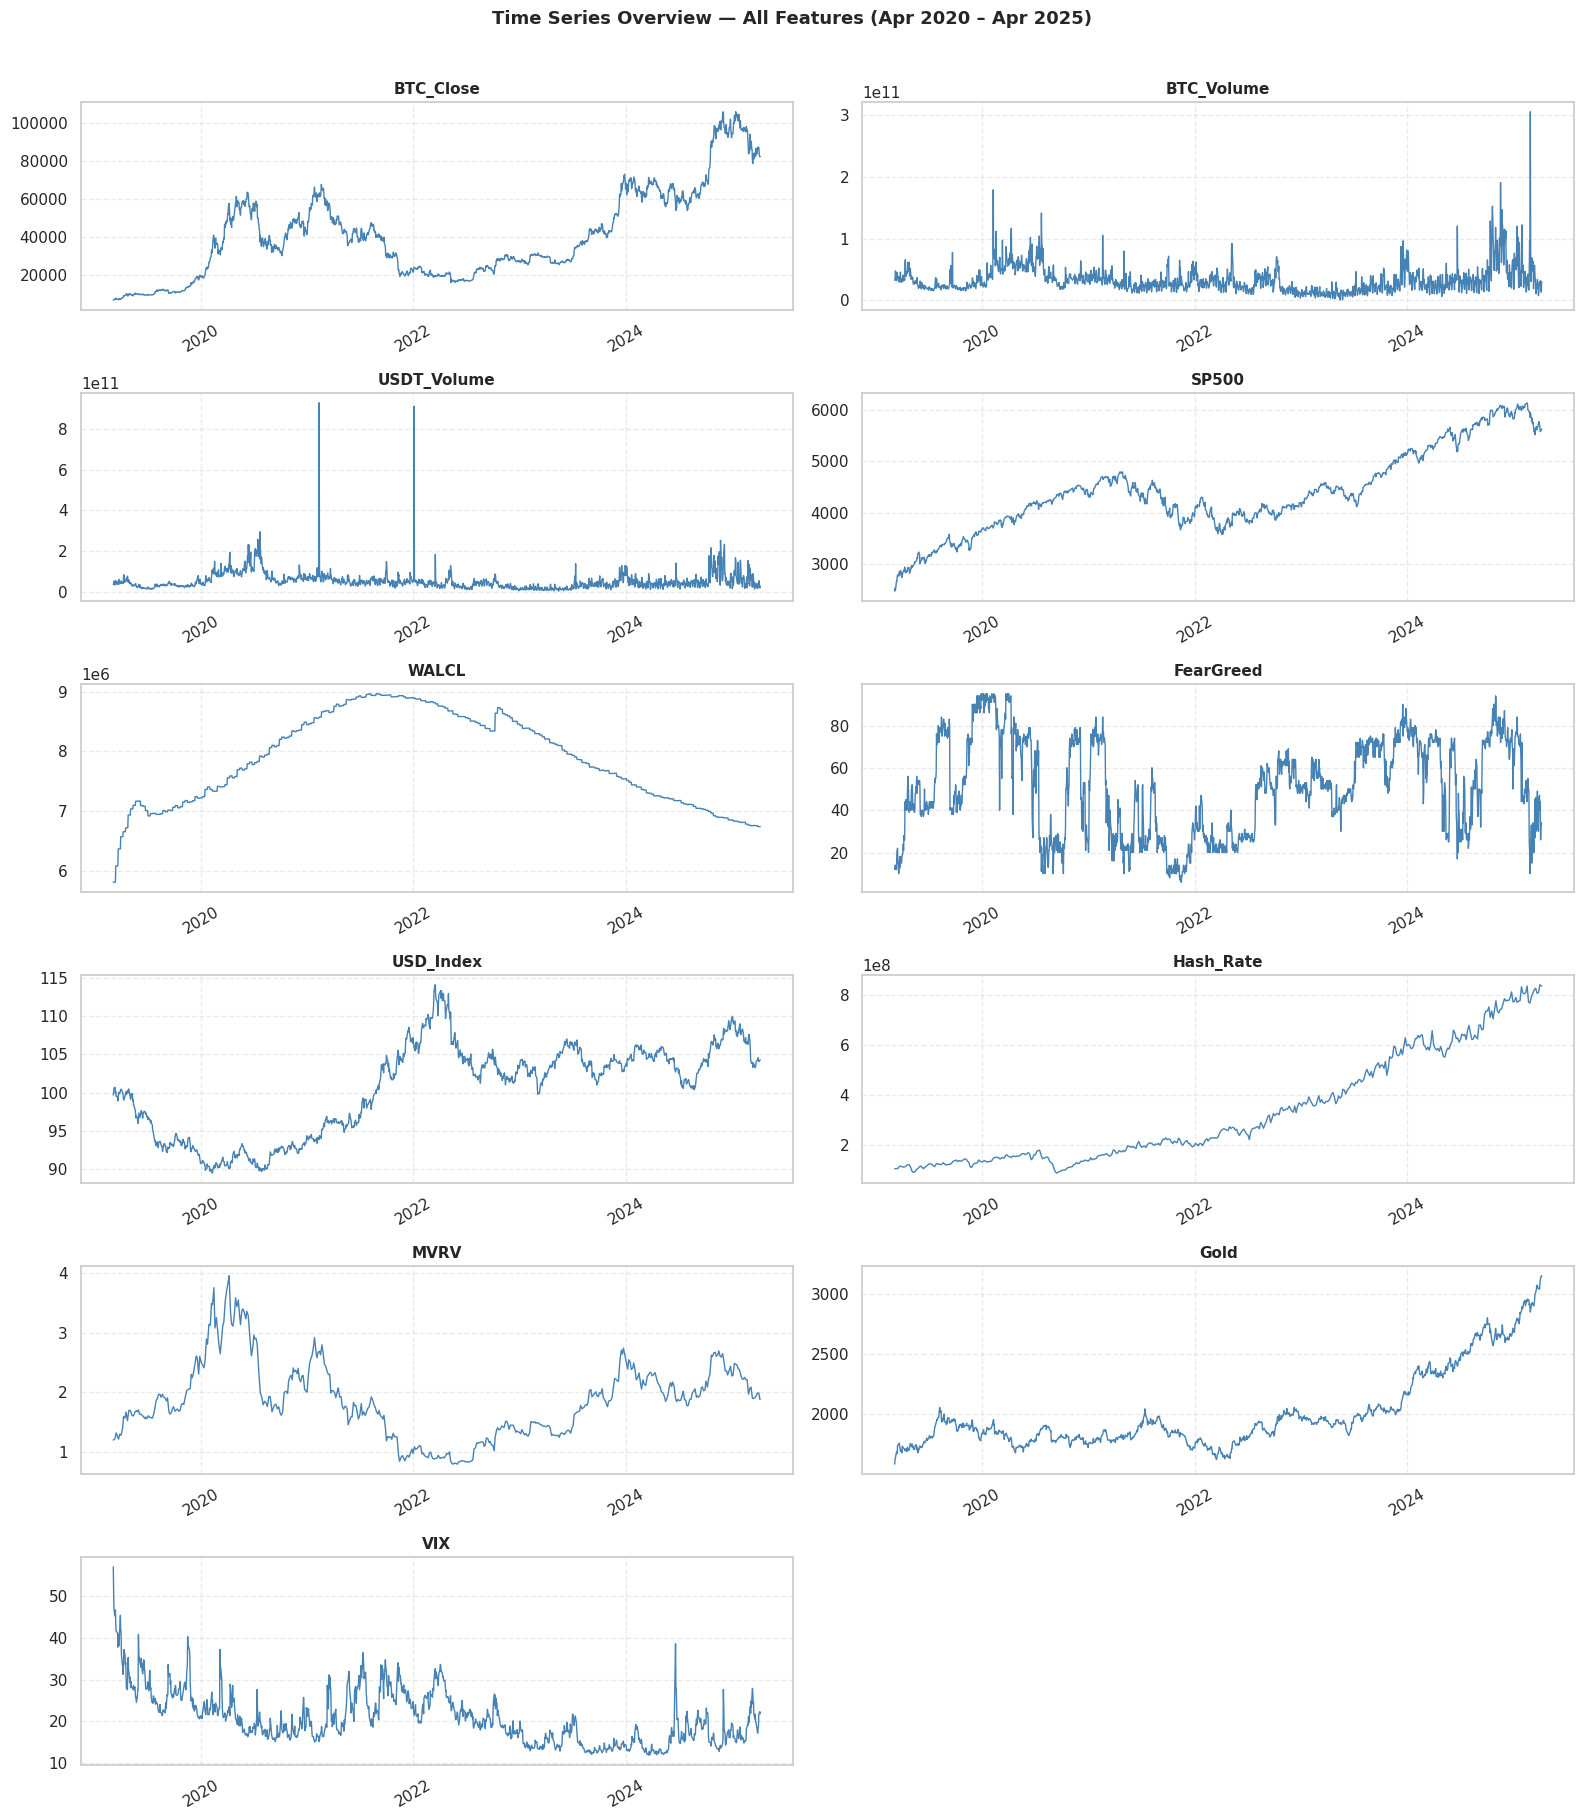

In [124]:
# =============================================================================
# TIME SERIES — All features
# =============================================================================

cols  = merged.columns.tolist()
n     = len(cols)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.plot(merged.index, merged[col], linewidth=1, color="steelblue")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Time Series Overview — All Features (Apr 2020 – Apr 2025)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [125]:
# =============================================================================
# OUTLIER ANALYSIS — IQR method for all features
# =============================================================================

records = []
for col in merged.columns:
    Q1  = merged[col].quantile(0.25)
    Q3  = merged[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((merged[col] < Q1 - 1.5 * IQR) |
             (merged[col] > Q3 + 1.5 * IQR)).sum()
    records.append({"Feature": col, "Q1": Q1, "Q3": Q3,
                    "IQR": IQR, "Outliers (IQR)": n_out})

outlier_df = pd.DataFrame(records).set_index("Feature")
outlier_df.round(2)

,Q1,Q3,IQR,Outliers (IQR)
Feature,,,,
BTC_Close,"21,992.57","57,442.27","35,449.69",0
BTC_Volume,"19,600,525,568.36","40,283,443,299.17","20,682,917,730.81",88
USDT_Volume,"29,797,138,075.33","63,748,241,742.79","33,951,103,667.46",107
SP500,"3,903.30","4,772.60",869.29,20
WALCL,"7,177,265.00","8,564,943.00","1,387,678.00",0
FearGreed,29.00,72.00,43.00,0
USD_Index,94.20,104.66,10.47,0
Hash_Rate,"150,140,767.82","513,027,263.97","362,886,496.15",0
MVRV,1.40,2.25,0.84,23


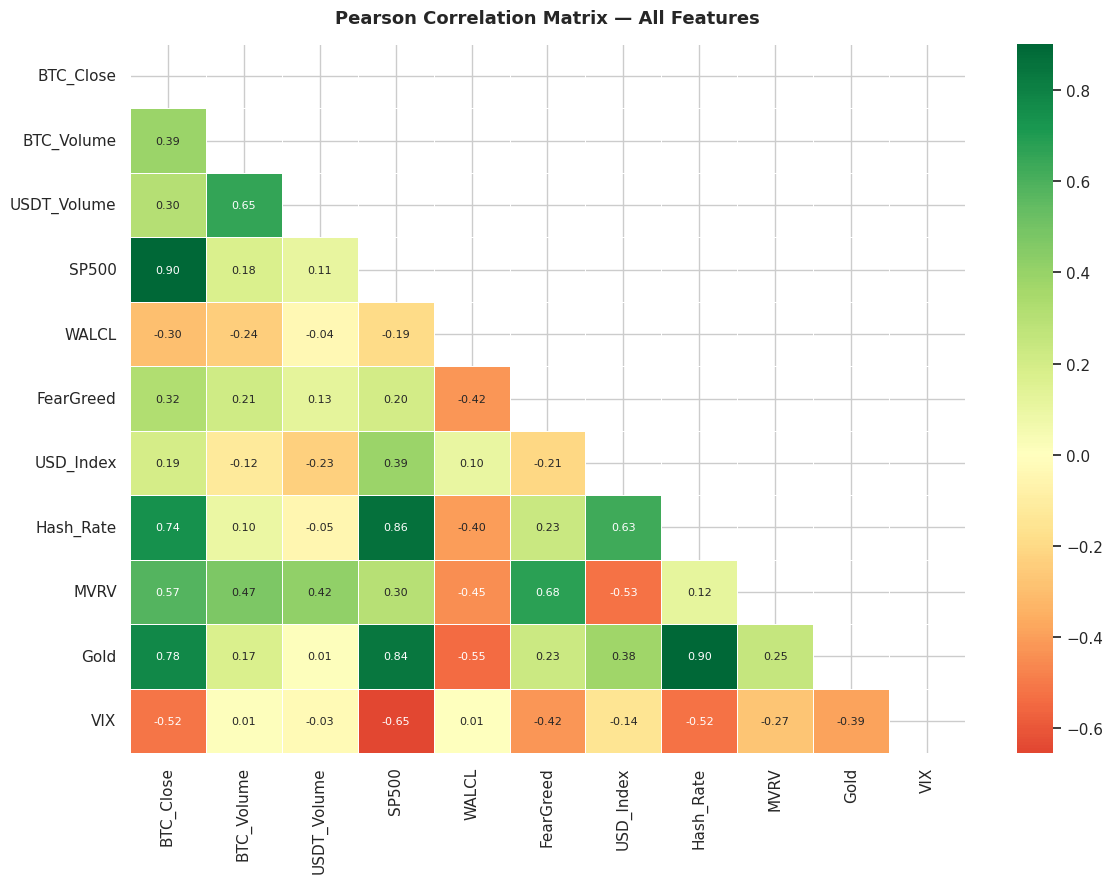

In [126]:
# =============================================================================
# CORRELATION HEATMAP
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 9))

corr = merged.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask       = mask,
    annot      = True,
    fmt        = ".2f",
    cmap       = "RdYlGn",
    center     = 0,
    linewidths = 0.5,
    ax         = ax,
    annot_kws  = {"size": 8}
)

ax.set_title("Pearson Correlation Matrix — All Features",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### EDA Key Observations

**Trend & non-stationarity**
- `BTC_Close` and `Gold` show clear upward trends — both are non-stationary in levels.
- `WALCL` expanded sharply in 2020 (COVID QE) and again in 2021, then contracted from 2022 as the Fed began quantitative tightening.
- `Hash_Rate` grew monotonically, reflecting continuous growth in Bitcoin mining infrastructure.

**Sentiment & volatility**
- `Fear & Greed` shows clear cyclical behaviour aligned with known BTC bull/bear cycles (2021 peak, 2022 crash, 2024 halving rally).
- `VIX` spikes correspond to macro stress events (COVID-19 March 2020, 2022 rate hikes).

**Outliers**
- `MVRV` outliers (n=23) correspond to known market extremes — bull market tops and bear market bottoms. These are economically meaningful and are **retained** in the dataset.
- `BTC_Volume` and `USDT_Volume` outliers reflect periods of intense market activity and are likewise retained.

**Correlations with BTC_Close**
- Strongest positive: `MVRV`, `SP500`, `Gold`, `WALCL`
- Strongest negative: `USD_Index` (consistent with the literature — Ahmadova et al., 2024)
- Near-zero in levels: `Hash_Rate`, `BTC_Volume`, `USDT_Volume` (may contribute more as lagged features)

---
## Section 5 · Modelling

All models predict `BTC_Close` (daily closing price in USD).

**Common conventions across all models:**
- Train/test split is **chronological** (`shuffle=False`) — no future data
  leaks into training
- The same **80/20 split** is used for all models to ensure fair comparison
- Evaluation metrics: RMSE, MAE, R²

**Models evaluated:**
1. Linear Regression (baseline)
2. LSTM
3. Random Forest
4. XGBoost

---
### Model 1 · Linear Regression (Baseline)

Linear Regression is used as a **benchmark** — its simplicity makes it a
useful reference point for evaluating more complex models.

To give the model temporal awareness, we add:
- `BTC_Close_lag1` and `BTC_Close_lag2` — previous 1 and 2 days closing price

All features are standardised using `StandardScaler` so that regression
coefficients are directly comparable across variables with very different
scales (e.g. BTC price ~$40,000 vs Fear & Greed ~50).

In [127]:
# =============================================================================
# MODEL 1 · LINEAR REGRESSION (BASELINE)
# =============================================================================

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Feature engineering ---
df_lr = merged.copy()
df_lr["BTC_Close_lag1"] = df_lr["BTC_Close"].shift(1)
df_lr["BTC_Close_lag2"] = df_lr["BTC_Close"].shift(2)
df_lr = df_lr.dropna()

X = df_lr.drop(columns=["BTC_Close"])
y = df_lr["BTC_Close"]

# --- Train / test split (80/20 chronological) ---
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# --- Scale features ---
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# --- Train ---
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

# --- Shared evaluation function (reused for all models) ---
def regression_report(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"  RMSE : ${rmse:>10,.2f}")
    print(f"  MAE  : ${mae:>10,.2f}")
    print(f"  R²   :  {r2:>10.4f}")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2}

y_train_pred = lr.predict(X_train_sc)
y_test_pred  = lr.predict(X_test_sc)

print("Linear Regression — Train:")
train_lr = regression_report("LR_train", y_train, y_train_pred)
print("\nLinear Regression — Test:")
test_lr  = regression_report("Linear Regression", y_test, y_test_pred)

# Store results for final comparison
all_results = [test_lr]

Linear Regression — Train:
  RMSE : $  1,174.09
  MAE  : $    764.69
  R²   :      0.9942

Linear Regression — Test:
  RMSE : $  2,160.81
  MAE  : $  1,590.73
  R²   :      0.9812


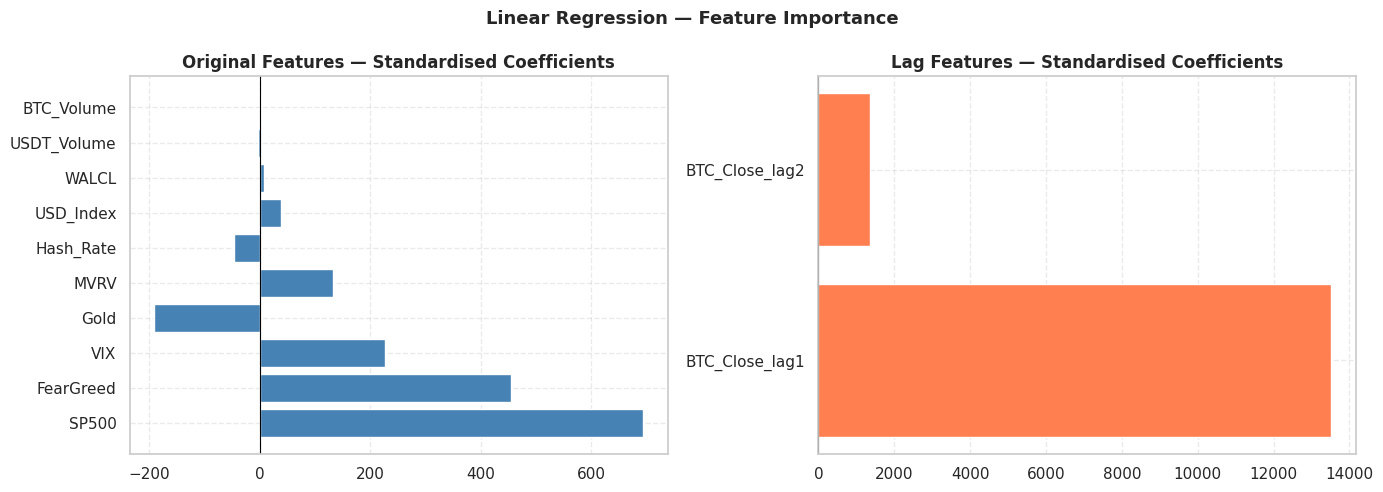

In [128]:
# FEATURE IMPORTANCE — Standardised coefficients

coef_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

original = coef_df[~coef_df["Feature"].str.contains("lag")]
lag      = coef_df[coef_df["Feature"].str.contains("lag")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color in zip(
    axes,
    [original, lag],
    ["Original Features — Standardised Coefficients",
     "Lag Features — Standardised Coefficients"],
    ["steelblue", "coral"]
):
    ax.barh(data["Feature"], data["Coefficient"], color=color)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Linear Regression — Feature Importance",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

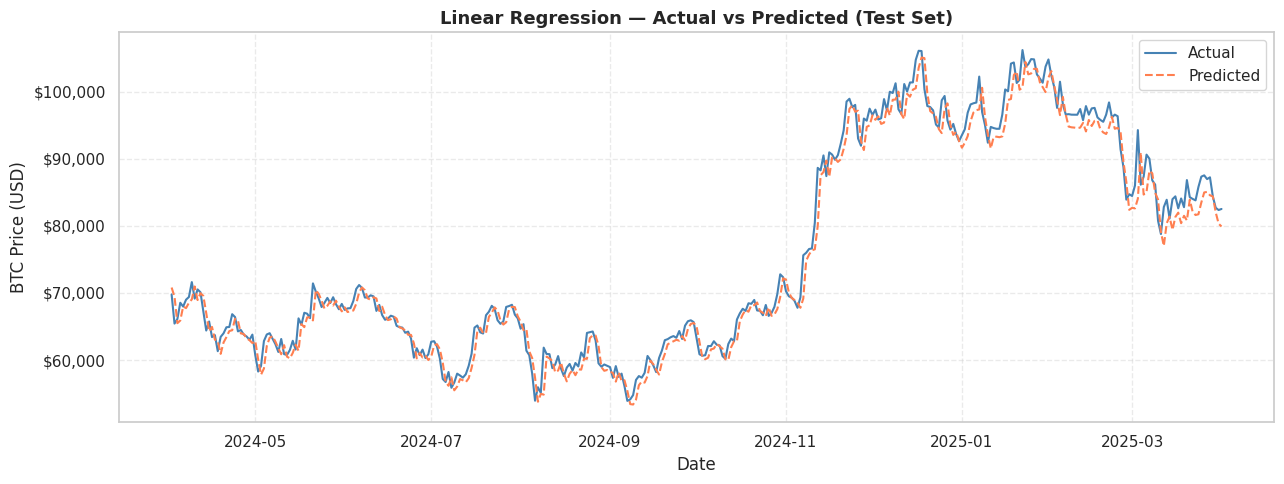

In [129]:
# ACTUAL vs PREDICTED — Test Set

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(y_test.index, y_test.values,
        label="Actual", color="steelblue", linewidth=1.5)
ax.plot(y_test.index, y_test_pred,
        label="Predicted", color="coral",
        linewidth=1.5, linestyle="--")

ax.set_title("Linear Regression — Actual vs Predicted (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("BTC Price (USD)")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Linear Regression — Observations

| Set   | RMSE      | MAE       | R²     |
|-------|-----------|-----------|--------|
| Train | 1,174.09 | 764.69   | 0.9942 |
| Test  | 2,160.81 | 1,590.73 | 0.9812 |

The baseline model performs strongly. The small gap between train and test
R² (0.9942 → 0.9812) indicates **no significant overfitting**.

**What drives performance:** The dominant features are the autoregressive
lags (`BTC_Close_lag1`, `BTC_Close_lag2`), which capture the high
day-to-day persistence of Bitcoin prices. This is expected — BTC price
tomorrow is strongly predicted by BTC price today.

Among the original features, `MVRV` shows the strongest positive
coefficient, consistent with its role as a market valuation signal.
`USD_Index` shows a negative coefficient, aligned with the literature
(Ahmadova et al., 2024).

**Limitation:** The strong performance is largely driven by the lag
features — in effect, the model is learning "tomorrow ≈ today". This is
useful for short-term forecasting but does not capture structural market
shifts. Any model evaluated here should outperform this baseline to
justify its added complexity.

---
### Model 2 · LSTM (Long Short-Term Memory)

LSTM is a type of Recurrent Neural Network designed for sequential data.
Unlike Linear Regression, it does not require explicit lag features —
it learns temporal dependencies internally through its memory architecture.

**Setup:**
- All features normalised to [0,1] using `MinMaxScaler`
- Sliding window of **60 days** — the model sees the last 60 days to
  predict the next day
- Architecture: 1 LSTM layer (50 units, tanh activation) + Dense output
- Optimizer: Adam | Loss: MSE | Epochs: 100
- Train/test split: 80/20 chronological (same as all models)

The window size and epochs were selected after testing multiple
configurations (window: 30/60/90, epochs: 50/100/150) — 60 days /
100 epochs provided the best balance between learning and generalisation.

In [130]:
# =============================================================================
# MODEL 2 · LSTM
# =============================================================================

import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler

# --- Reproducibility ---
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

df_lstm = merged.copy()
target_col = "BTC_Close"

# --- Train/test split FIRST (80/20 chronological) ---
# Split must happen before any scaling to prevent data leakage
split = int(len(df_lstm) * 0.8)
train_df = df_lstm.iloc[:split]
test_df  = df_lstm.iloc[split:]

# --- Scale features: fit only on train, transform both ---
feature_scaler = MinMaxScaler()
train_scaled = feature_scaler.fit_transform(train_df)
test_scaled  = feature_scaler.transform(test_df)

# --- Scale target: fit only on train ---
target_scaler = MinMaxScaler()
train_target = target_scaler.fit_transform(
    train_df[[target_col]]
)
test_target = target_scaler.transform(
    test_df[[target_col]]
)

# Convert to DataFrames for easier indexing
train_scaled_df = pd.DataFrame(
    train_scaled, columns=df_lstm.columns, index=train_df.index
)
test_scaled_df = pd.DataFrame(
    test_scaled, columns=df_lstm.columns, index=test_df.index
)

# --- Sliding window (60 days) ---
window_size = 60

def make_sequences(scaled_df, scaled_target, window_size):
    X, y = [], []
    for i in range(window_size, len(scaled_df)):
        X.append(scaled_df.iloc[i-window_size:i].values)
        y.append(scaled_target[i][0])
    return np.array(X), np.array(y)

# For train sequences: use only train data
X_train_s, y_train_s = make_sequences(
    train_scaled_df, train_target, window_size
)

# For test sequences: we need the last 60 days of train
# to build the first test window, it is not leakage
# because we use past data to predict future
combined_scaled = pd.concat([train_scaled_df, test_scaled_df])
combined_target = np.concatenate([train_target, test_target])

X_all, y_all = make_sequences(combined_scaled, combined_target, window_size)
X_test_s = X_all[len(X_train_s):]
y_test_s = y_all[len(y_train_s):]

print(f"Train sequences : {X_train_s.shape}")
print(f"Test sequences  : {X_test_s.shape}")
print(f"\nScaler fit on train only: {train_df.index.min().date()} → {train_df.index.max().date()}")
print(f"No test data seen during scaling ✓")

Train sequences : (1401, 60, 11)
Test sequences  : (366, 60, 11)

Scaler fit on train only: 2020-04-01 → 2024-03-31
No test data seen during scaling ✓


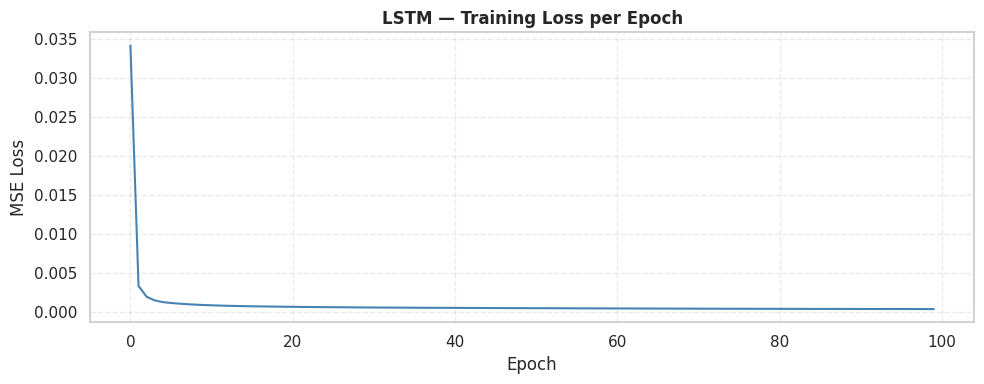

In [131]:
# --- Build & train model ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model_lstm = Sequential([
    Input(shape=(X_train_s.shape[1], X_train_s.shape[2])),
    LSTM(50, activation="tanh"),
    Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mse")

history = model_lstm.fit(
    X_train_s, y_train_s,
    epochs     = 100,
    batch_size = 32,
    verbose    = 0
)

# --- Training loss curve ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"], color="steelblue", linewidth=1.5)
ax.set_title("LSTM — Training Loss per Epoch", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [132]:
# --- Predict & inverse transform ---
y_pred_scaled = model_lstm.predict(X_test_s)
y_pred_actual = target_scaler.inverse_transform(y_pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test_s.reshape(-1, 1))

# --- Metrics ---
print("LSTM — Train:")
y_train_pred_scaled = model_lstm.predict(X_train_s)
y_train_pred_actual = target_scaler.inverse_transform(y_train_pred_scaled)
y_train_actual      = target_scaler.inverse_transform(y_train_s.reshape(-1, 1))
train_lstm = regression_report("LSTM_train", y_train_actual, y_train_pred_actual)

print("\nLSTM — Test:")
test_lstm = regression_report("LSTM", y_test_actual, y_pred_actual)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
LSTM — Train:
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
  RMSE : $  1,383.72
  MAE  : $  1,071.25
  R²   :      0.9915

LSTM — Test:
  RMSE : $  2,266.09
  MAE  : $  1,774.91
  R²   :      0.9793


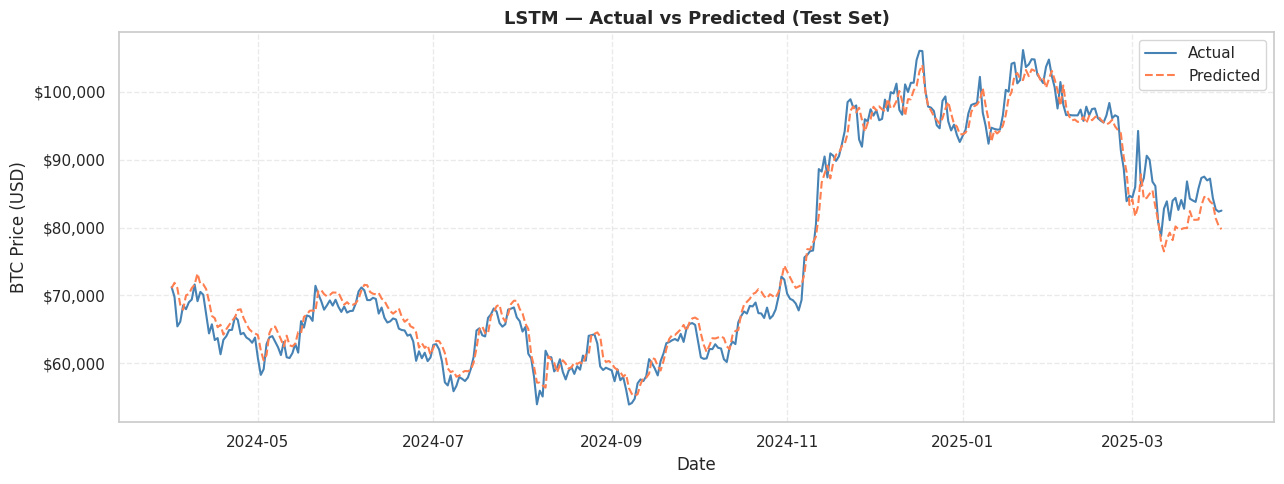

In [133]:
# --- Actual vs Predicted ---
test_dates = test_df.index

y_pred_actual_flat = y_pred_actual.flatten()
y_test_actual_flat = y_test_actual.flatten()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, y_test_actual_flat,
        label="Actual", color="steelblue", linewidth=1.5)
ax.plot(test_dates, y_pred_actual_flat,
        label="Predicted", color="coral",
        linewidth=1.5, linestyle="--")

ax.set_title("LSTM — Actual vs Predicted (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("BTC Price (USD)")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### LSTM — Observations

| Set   | RMSE      | MAE       | R²     |
|-------|-----------|-----------|--------|
| Train | 1,383.72 | 1,071.25 | 0.9915 |
| Test  | 2,266.09 | 1,774.91 | 0.9793 |

**Implementation note:** A key design decision in this model was the
order of operations — the train/test split was performed before
fitting the MinMaxScaler. The scaler was fit exclusively on the training
set and then applied to the test set. This prevents data leakage, where
the model would otherwise have indirect knowledge of the test set's
value range during training — a common mistake in time series ML that
leads to overly optimistic metrics.

The model captures both the overall trend and short-term fluctuations
well. It still slightly underestimates sharp peaks (e.g. January 2025
at 106K) — a known limitation of MSE-trained models which learn
conservative, central predictions to minimise large errors.

**vs Linear Regression:** The two models are now comparable — RMSE
2,266 vs 2,161, R² 0.979 vs 0.981. This is notable given that the
LSTM uses no explicit lag features and learns temporal patterns purely
from the 60-day sequence window, while Linear Regression relies directly
on yesterday's price as a feature.

### Model 3 · Random Forest

Random Forest is an ensemble method that builds multiple decision trees
and averages their predictions. Unlike Linear Regression, it captures
non-linear relationships and feature interactions without assumptions
about the data distribution.

**Key challenge for time series:** Random Forest has no built-in temporal
awareness — it treats each row independently. To give it memory, we add:
- Lag features (t-1, t-2) for all variables
- Rolling mean & std for `BTC_Close` with windows of 3, 5, 7 days

**Note on tree-based models and time series:** Decision trees cannot
extrapolate beyond the range of values seen during training. This is a
known limitation that becomes visible when the test set contains price
levels not present in training data.

**Setup:**
- Train/test split: 80/20 chronological
- `n_estimators=100`, `max_depth=8`, `min_samples_leaf=5`

In [134]:
# =============================================================================
# MODEL 3 · RANDOM FOREST
# =============================================================================

from sklearn.ensemble import RandomForestRegressor

# --- Feature engineering ---
df_rf = merged.copy()

# Lag features for all variables
for col in df_rf.columns:
    if col != "BTC_Close":
        df_rf[f"{col}_lag1"] = df_rf[col].shift(1)
        df_rf[f"{col}_lag2"] = df_rf[col].shift(2)

# Lag features for target
df_rf["BTC_Close_lag1"] = df_rf["BTC_Close"].shift(1)
df_rf["BTC_Close_lag2"] = df_rf["BTC_Close"].shift(2)

# Rolling features for BTC_Close
for window in [3, 5, 7]:
    df_rf[f"BTC_Close_roll{window}"] = df_rf["BTC_Close"].rolling(window).mean()
    df_rf[f"BTC_Close_std{window}"]  = df_rf["BTC_Close"].rolling(window).std()

df_rf = df_rf.dropna()

X = df_rf.drop(columns=["BTC_Close"])
y = df_rf["BTC_Close"]

# --- Train/test split (80/20 chronological) ---
split = int(len(X) * 0.8)
X_train_rf, X_test_rf = X.iloc[:split], X.iloc[split:]
y_train_rf, y_test_rf = y.iloc[:split], y.iloc[split:]

print(f"Train : {X_train_rf.shape[0]:,} rows | {X_train_rf.shape[1]} features")
print(f"Test  : {X_test_rf.shape[0]:,} rows")
print(f"Train period: {X_train_rf.index.min().date()} → {X_train_rf.index.max().date()}")
print(f"Test period : {X_test_rf.index.min().date()} → {X_test_rf.index.max().date()}")

Train : 1,456 rows | 38 features
Test  : 365 rows
Train period: 2020-04-07 → 2024-04-01
Test period : 2024-04-02 → 2025-04-01


In [135]:
# --- Train ---
rf = RandomForestRegressor(
    n_estimators    = 100,
    max_depth       = 8,
    min_samples_leaf= 5,
    min_samples_split=10,
    random_state    = 42,
    n_jobs          = -1
)
rf.fit(X_train_rf, y_train_rf)

# --- Evaluate ---
y_train_pred_rf = rf.predict(X_train_rf)
y_test_pred_rf  = rf.predict(X_test_rf)

print("Random Forest — Train:")
train_rf = regression_report("RF_train", y_train_rf, y_train_pred_rf)
print("\nRandom Forest — Test:")
test_rf  = regression_report("Random Forest", y_test_rf, y_test_pred_rf)

Random Forest — Train:
  RMSE : $    548.00
  MAE  : $    338.29
  R²   :      0.9987

Random Forest — Test:
  RMSE : $ 15,531.62
  MAE  : $ 10,410.48
  R²   :      0.0287


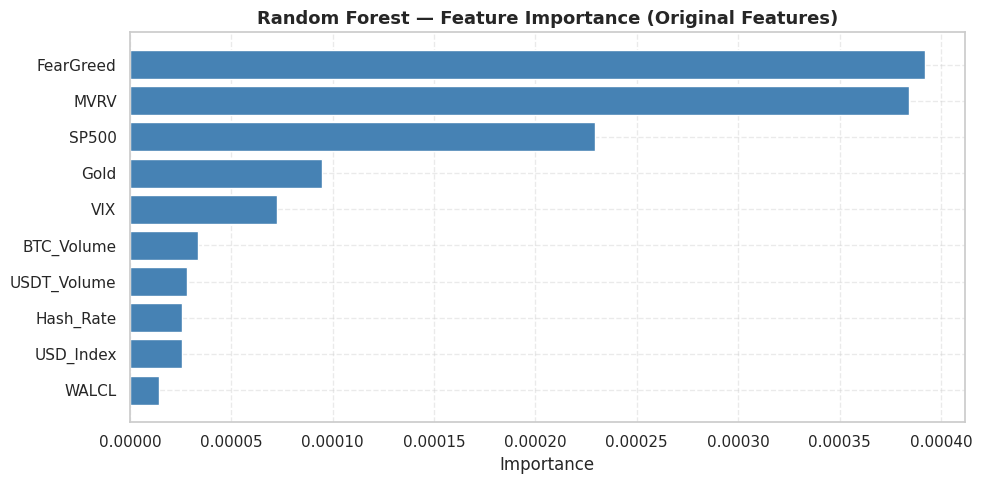

In [136]:
# --- Feature Importance (original features only) ---
importance_df = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": rf.feature_importances_
})

# Keep only original features (no lag/roll)
original_imp = importance_df[
    ~importance_df["Feature"].str.contains("lag|roll|std", case=False)
].sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(original_imp["Feature"], original_imp["Importance"], color="steelblue")
ax.set_title("Random Forest — Feature Importance (Original Features)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
ax.gca().invert_yaxis() if hasattr(ax, 'gca') else ax.invert_yaxis()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

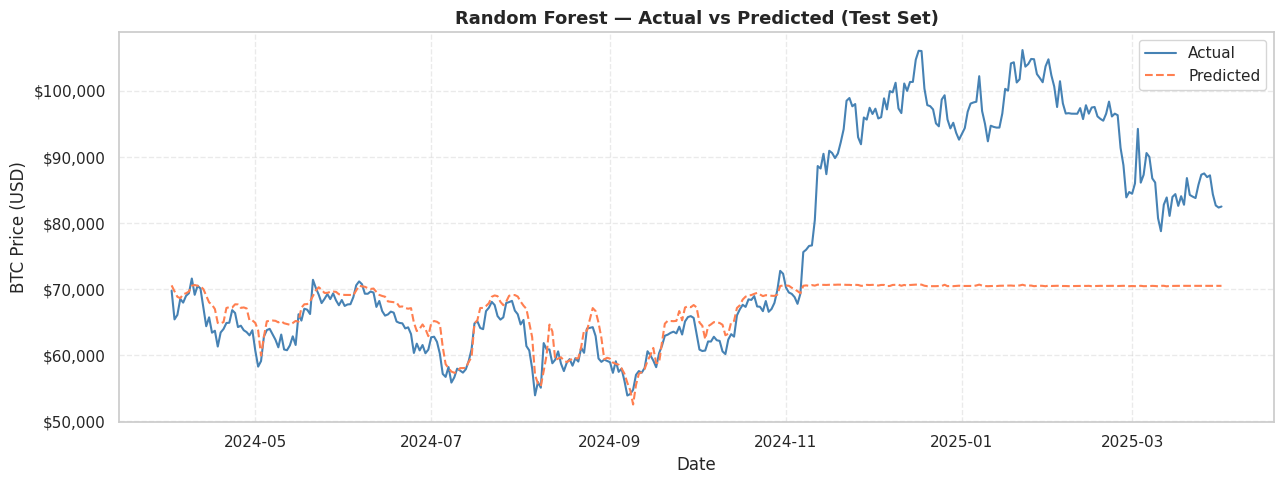

In [137]:
# --- Actual vs Predicted ---
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test_rf.index, y_test_rf.values,
        label="Actual", color="steelblue", linewidth=1.5)
ax.plot(y_test_rf.index, y_test_pred_rf,
        label="Predicted", color="coral",
        linewidth=1.5, linestyle="--")

ax.set_title("Random Forest — Actual vs Predicted (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("BTC Price (USD)")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Random Forest — Observations

| Set   | RMSE       | MAE        | R²     |
|-------|------------|------------|--------|
| Train | 548.00    | 338.29    | 0.9987 |
| Test  | 15,531.62 | 10,410.48 | 0.0287 |

The Random Forest exhibits severe overfitting combined with a fundamental
limitation of tree-based models: **extrapolation failure**.

Decision trees partition the feature space based on values seen during
training. The training set contains BTC prices up to 70K. When the test
set includes the November 2024 rally to 106K — price levels never seen
during training — the model has no mechanism to extrapolate. It predicts
the highest value it has seen, visible in the plot as a flat line at
70,000 from November 2024 onwards.

Multiple configurations were tested (varying max_depth, n_estimators,
min_samples_leaf, and feature selection) — none produced meaningful
improvement on the test set under the 80/20 chronological split. This
confirms that the limitation is structural, not a tuning issue.

**Key insight:** This is a known and documented limitation of tree-based
models for trending time series. Linear Regression and LSTM do not suffer
from this because they can extrapolate beyond the training range — linear
models through their coefficients, and LSTM through its learned temporal
dynamics.

**Feature importance:** Despite poor predictive performance, the feature
ranking is informative — `FearGreed` and `MVRV` dominate, consistent with
Linear Regression findings. This suggests these variables carry genuine
signal about Bitcoin market dynamics, even if the model cannot exploit it
effectively in this setting.

---
### Model 4 · XGBoost

XGBoost (Extreme Gradient Boosting) builds trees sequentially — each tree
corrects the errors of the previous one. Unlike Random Forest which builds
trees in parallel, XGBoost is more sensitive to hyperparameters and
typically achieves better performance with proper tuning.

As with Random Forest, XGBoost faces the same extrapolation limitation —
being a tree-based model it cannot predict values outside the training
range. Results should be interpreted with this in mind.

**Setup:**
- Lag features (t-1, t-2) for all variables
- Rolling mean & std for BTC_Close (windows 3, 5, 7)
- Train/test split: 80/20 chronological
- `n_estimators=200`, `max_depth=4`, `learning_rate=0.05`

In [138]:
# =============================================================================
# MODEL 4 · XGBOOST
# =============================================================================

# --- Feature engineering ---
df_xgb = merged.copy()

for col in df_xgb.columns:
    if col != "BTC_Close":
        df_xgb[f"{col}_lag1"] = df_xgb[col].shift(1)
        df_xgb[f"{col}_lag2"] = df_xgb[col].shift(2)

df_xgb["BTC_Close_lag1"] = df_xgb["BTC_Close"].shift(1)
df_xgb["BTC_Close_lag2"] = df_xgb["BTC_Close"].shift(2)

for window in [3, 5, 7]:
    df_xgb[f"BTC_Close_roll{window}"] = df_xgb["BTC_Close"].rolling(window).mean()
    df_xgb[f"BTC_Close_std{window}"]  = df_xgb["BTC_Close"].rolling(window).std()

df_xgb = df_xgb.dropna()
X = df_xgb.drop(columns=["BTC_Close"])
y = df_xgb["BTC_Close"]

split = int(len(X) * 0.8)
X_train_xgb, X_test_xgb = X.iloc[:split], X.iloc[split:]
y_train_xgb, y_test_xgb = y.iloc[:split], y.iloc[split:]

print(f"Train : {X_train_xgb.shape[0]:,} rows | {X_train_xgb.shape[1]} features")
print(f"Test  : {X_test_xgb.shape[0]:,} rows")
print(f"Train period: {X_train_xgb.index.min().date()} → {X_train_xgb.index.max().date()}")
print(f"Test period : {X_test_xgb.index.min().date()} → {X_test_xgb.index.max().date()}")

Train : 1,456 rows | 38 features
Test  : 365 rows
Train period: 2020-04-07 → 2024-04-01
Test period : 2024-04-02 → 2025-04-01


In [139]:
# --- Train ---
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    objective        = "reg:squarederror",
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42
)
xgb_model.fit(X_train_xgb, y_train_xgb)

y_train_pred_xgb = xgb_model.predict(X_train_xgb)
y_test_pred_xgb  = xgb_model.predict(X_test_xgb)

print("XGBoost - Train:")
train_xgb = regression_report("XGB_train", y_train_xgb, y_train_pred_xgb)
print("\nXGBoost - Test:")
test_xgb = regression_report("XGBoost", y_test_xgb, y_test_pred_xgb)

XGBoost - Train:
  RMSE : $    376.08
  MAE  : $    274.61
  R²   :      0.9994

XGBoost - Test:
  RMSE : $ 17,004.02
  MAE  : $ 10,897.33
  R²   :     -0.1642


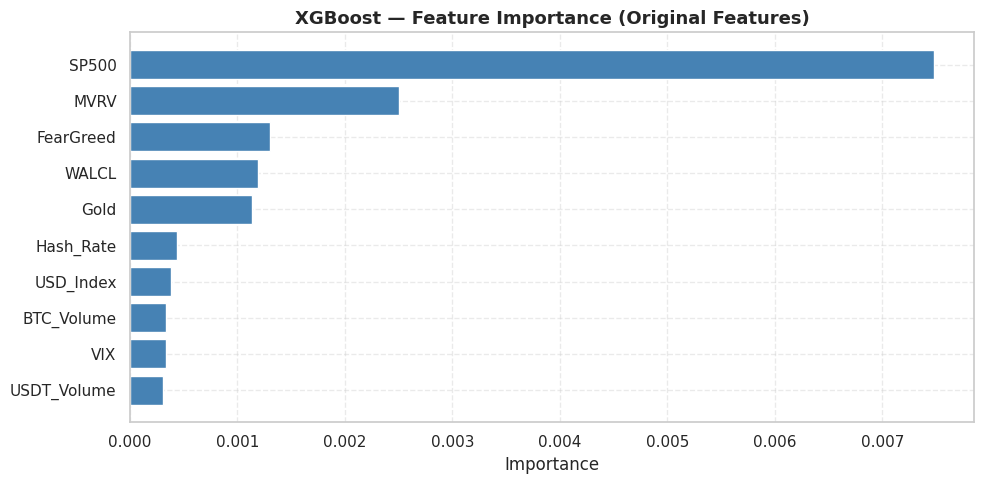

In [140]:
# --- Feature Importance ---
importance_xgb = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

original_imp_xgb = importance_xgb[
    ~importance_xgb["Feature"].str.contains("lag|roll|std", case=False)
].sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(original_imp_xgb["Feature"], original_imp_xgb["Importance"],
        color="steelblue")
ax.set_title("XGBoost — Feature Importance (Original Features)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
ax.invert_yaxis()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

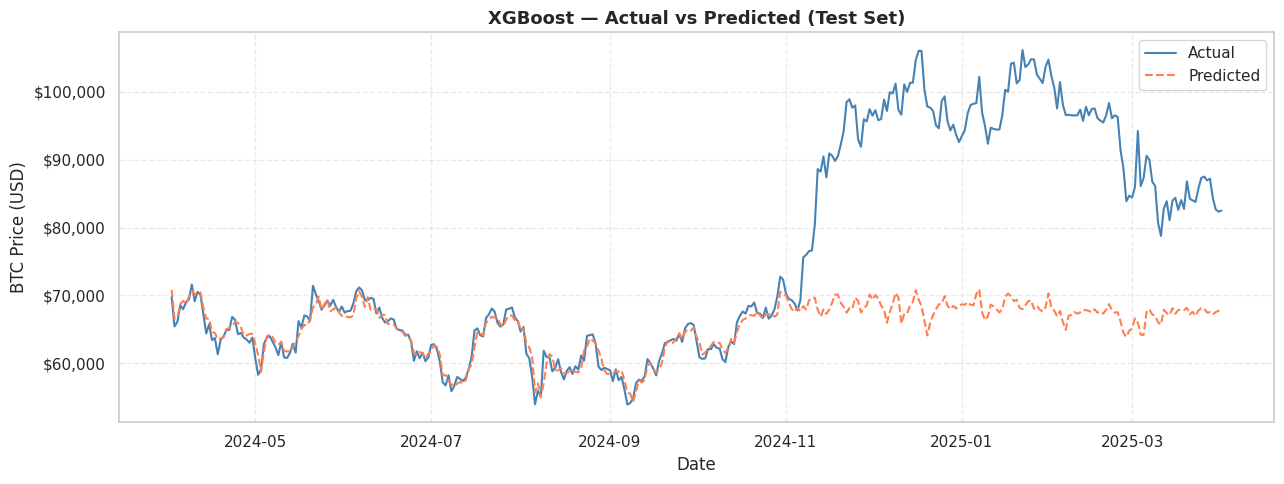

In [141]:
# --- Actual vs Predicted ---
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test_xgb.index, y_test_xgb.values,
        label="Actual", color="steelblue", linewidth=1.5)
ax.plot(y_test_xgb.index, y_test_pred_xgb,
        label="Predicted", color="coral",
        linewidth=1.5, linestyle="--")

ax.set_title("XGBoost — Actual vs Predicted (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("BTC Price (USD)")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### XGBoost — Observations

| Set   | RMSE       | MAE        | R²      |
|-------|------------|------------|---------|
| Train | 376.08    | 274.61    | 0.9994  |
| Test  | 17,004.02 | 10,897.33 | -0.1642 |

XGBoost exhibits the same structural limitation as Random Forest —
near-perfect training performance followed by complete failure on the
test set due to extrapolation failure. The predicted line flattens at 70,000 from November 2024 onwards, unable to follow the actual rally
to 106,000.

The train R² of 0.9994 — even higher than Random Forest — reflects
XGBoost's tendency to overfit more aggressively due to its sequential
boosting nature, which corrects errors iteratively and can memorise
training patterns.

**Feature importance:** SP500 dominates overwhelmingly, followed by
MVRV and FearGreed. This differs from Random Forest where FearGreed
ranked first — the difference reflects how each algorithm measures
importance. XGBoost uses gain (improvement in loss per split) while
Random Forest uses impurity reduction. SP500's dominance in XGBoost
suggests it provides the most consistent error reduction across all
boosting rounds, capturing the broad market regime that drives BTC price.

**Consistent finding across all models:** SP500, MVRV, and FearGreed
appear in the top features across Linear Regression, Random Forest, and
XGBoost — reinforcing that these three variables carry the most
meaningful signal about Bitcoin price dynamics.

In [142]:
all_results = [
    {
        "Model": "Linear Regression",
        "RMSE" : 2160.81,
        "MAE"  : 1590.73,
        "R²"   : 0.9812
    },
    {
        "Model": "LSTM",
        "RMSE" : 2266.09,
        "MAE"  : 1774.91,
        "R²"   : 0.9793
    },
    {
        "Model": "Random Forest",
        "RMSE" : 15531.62,
        "MAE"  : 10410.48,
        "R²"   : 0.0287
    },
    {
        "Model": "XGBoost",
        "RMSE" : 17004.02,
        "MAE"  : 10897.33,
        "R²"   : -0.1642
    },
]

df_results = pd.DataFrame(all_results).set_index("Model")
print(df_results.round(4))

                       RMSE       MAE    R²
Model                                      
Linear Regression  2,160.81  1,590.73  0.98
LSTM               2,266.09  1,774.91  0.98
Random Forest     15,531.62 10,410.48  0.03
XGBoost           17,004.02 10,897.33 -0.16


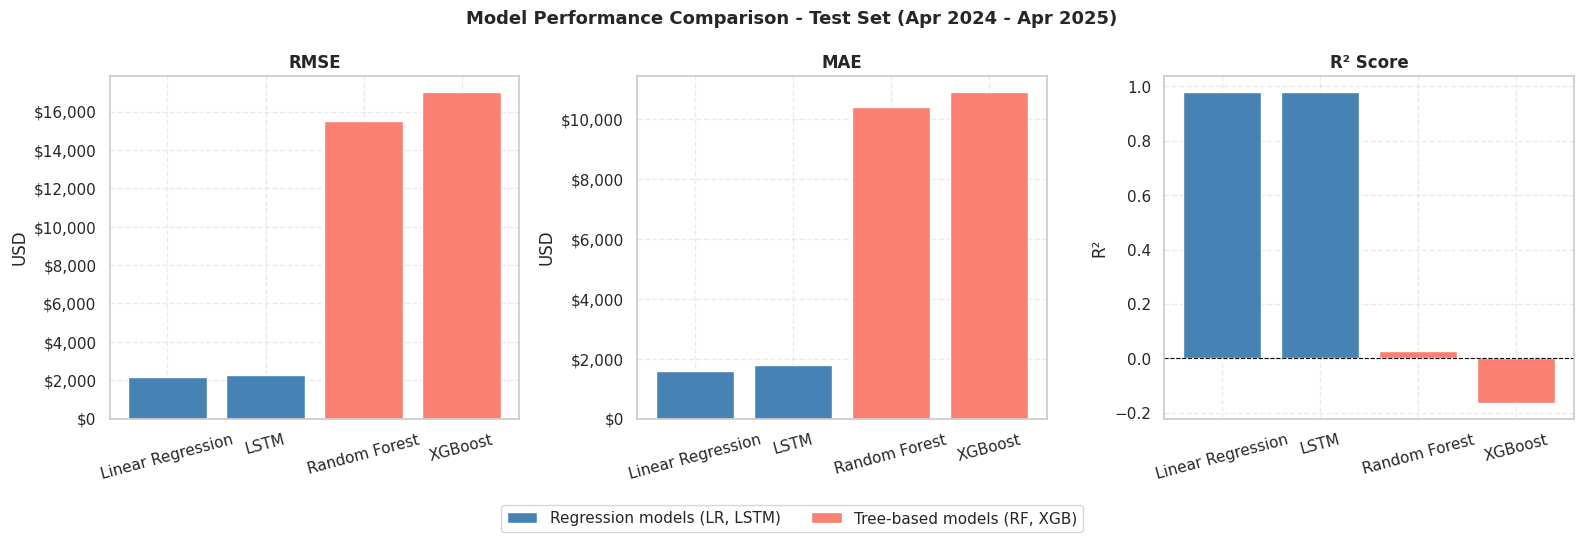

In [143]:
# =============================================================================
# SECTION 6 · MODEL COMPARISON
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = df_results.index.tolist()
colors = ["steelblue", "steelblue", "salmon", "salmon"]

# --- RMSE ---
axes[0].bar(models, df_results["RMSE"], color=colors)
axes[0].set_title("RMSE", fontweight="bold")
axes[0].set_ylabel("USD")
axes[0].tick_params(axis="x", rotation=15)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
axes[0].grid(True, linestyle="--", alpha=0.4)

# --- MAE ---
axes[1].bar(models, df_results["MAE"], color=colors)
axes[1].set_title("MAE", fontweight="bold")
axes[1].set_ylabel("USD")
axes[1].tick_params(axis="x", rotation=15)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
axes[1].grid(True, linestyle="--", alpha=0.4)

# --- R² ---
axes[2].bar(models, df_results["R²"], color=colors)
axes[2].set_title("R² Score", fontweight="bold")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=15)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].grid(True, linestyle="--", alpha=0.4)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="Regression models (LR, LSTM)"),
    Patch(facecolor="salmon",    label="Tree-based models (RF, XGB)")
]
plt.suptitle("Model Performance Comparison - Test Set (Apr 2024 - Apr 2025)",
             fontsize=13, fontweight="bold")

fig.legend(handles=legend_elements,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.08),
           ncol=2)

plt.tight_layout()
plt.show()

In [144]:
# RESULTS TABLE

# Styled table
display(df_results.style
    .format({
        "RMSE": "${:,.2f}",
        "MAE" : "${:,.2f}",
        "R²"  : "{:.4f}"
    })
    .background_gradient(subset=["R²"],  cmap="RdYlGn")
    .background_gradient(subset=["RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["MAE"],  cmap="RdYlGn_r")
    .set_caption("Model Performance — Test Set")
)

,RMSE,MAE,R²
Model,,,
Linear Regression,"$2,160.81","$1,590.73",0.9812
LSTM,"$2,266.09","$1,774.91",0.9793
Random Forest,"$15,531.62","$10,410.48",0.0287
XGBoost,"$17,004.02","$10,897.33",-0.1642


---
## Section 7 · Conclusions

### Summary of Results

| Model | RMSE | R² | Notes |
|---|---|---|---|
| Linear Regression | 2,161 | 0.981 | Best overall performance |
| LSTM | 2,266 | 0.979 | Comparable to baseline |
| Random Forest | 15,532 | 0.029 | Extrapolation failure |
| XGBoost | 17,004 | -0.164 | Extrapolation failure |

### Key Findings

**1. Linear models outperform tree-based models on this dataset**
Linear Regression and LSTM achieve comparable performance (R² ~0.98),
while Random Forest and XGBoost fail to generalise to the test set.
The gap is not due to model complexity but to a fundamental structural
limitation: tree-based models cannot extrapolate beyond the price range
seen during training. When BTC surged from ~70K to ~106K in November
2024, levels never seen in training, both models predicted a flat line.

**2. The dominant predictive features are consistent across models**
Despite the performance gap, all models agree on the most important
variables: SP500, MVRV, and Fear & Greed Index consistently rank as
the top predictors. This convergence across different model families
strengthens confidence in these findings.

- `SP500` captures broad market risk appetite — when equity markets
  rally, Bitcoin tends to follow
- `MVRV` is the strongest on-chain signal — high values indicate
  overvaluation and potential sell pressure
- `Fear & Greed Index` reflects retail sentiment cycles that directly
  drive short-term BTC price movements

**3. High R² in time series requires careful interpretation**
The strong performance of Linear Regression (R²=0.981) is largely
driven by autoregressive lag features. A naive baseline (tomorrow = today)
achieves R²=0.984, confirming that high R² alone is not sufficient
evidence of predictive power in trending time series.

**4. LSTM is competitive without explicit lag features**
The LSTM achieves R²=0.979 without any manually engineered lag features,
learning temporal dependencies directly from the 60-day sequence window.
This makes it more robust in principle for scenarios where yesterday's
price is not available as input.

### Limitations

- **Extrapolation:** Tree-based models fail on price levels not seen
  during training — a structural limitation for trending assets
- **Non-stationarity:** All models are trained on price levels rather
  than returns. A returns-based approach would be more theoretically
  sound.
- **Single test period:** The test set covers a specific bull market
  period (Apr 2024 - Apr 2025). Results may differ across different
  market regimes
- **No walk-forward validation:** A rolling retraining approach would
  provide more robust out-of-sample estimates